# Лабораторная работа 3 - Библиотеки Numpy и Scipy. Обработка табличных данных. Аппроксимация
## Подготовил студент группы 523 Чех Степан ##

## Вариант 15

## Задание 1.

Сгенерируйте массив случайных чисел длиной 100. Найдите наибольший и наименьший элементы, а также их индексы. Отсортируйте массив по возрастанию и убыванию.

In [1]:
import numpy as np
import scipy as sp
import random
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
random_array = np.random.randint(0, 10000, size=100)
sorted_array = np.sort(random_array)
reverse_sorted_array = sorted_array[::-1]

# Вывод массивов
print(*random_array)
print(*sorted_array)
print(*reverse_sorted_array)

# Поиск экстремумов и индексов
min_val = random_array.min()
min_idx = random_array.argmin()
max_val = random_array.max()
max_idx = random_array.argmax()

print(f"\nМинимальное значение равно {min_val}, индекс этого значения - {min_idx}.")
print(f"Максимальное значение равно {max_val}, индекс этого значения - {max_idx}.")

9922 6060 712 4308 1824 1219 284 5482 2844 9347 4927 4237 9717 3953 9207 7228 1856 3615 5610 2373 3236 8838 7678 8655 2971 2417 5799 2369 5410 513 4513 3391 4884 7996 1160 3013 7826 6016 8076 8925 3602 9133 5238 2326 8910 5259 7631 6283 9603 739 8702 764 1626 2346 6297 8479 2 3480 2317 1511 4758 6194 3660 7407 6157 2320 1091 4887 5508 4988 2756 216 4495 7388 4483 7674 2117 5520 9343 3280 1864 8033 7393 2899 7024 7134 2787 2817 7428 8016 3901 7680 1863 1915 9691 5404 8200 8926 6585 3163
2 216 284 513 712 739 764 1091 1160 1219 1511 1626 1824 1856 1863 1864 1915 2117 2317 2320 2326 2346 2369 2373 2417 2756 2787 2817 2844 2899 2971 3013 3163 3236 3280 3391 3480 3602 3615 3660 3901 3953 4237 4308 4483 4495 4513 4758 4884 4887 4927 4988 5238 5259 5404 5410 5482 5508 5520 5610 5799 6016 6060 6157 6194 6283 6297 6585 7024 7134 7228 7388 7393 7407 7428 7631 7674 7678 7680 7826 7996 8016 8033 8076 8200 8479 8655 8702 8838 8910 8925 8926 9133 9207 9343 9347 9603 9691 9717 9922
9922 9717 9691 960

## Задание 2.

Произведите интерполяцию и аппроксимацию табличной функции (согласно варианту) встроенными в Python функциями scipy.interpolate.interp1d() и numpy.polyfit внутри имеющегося диапазона значения.

In [16]:
x = np.array([1.73, 2.56, 3.39, 4.22, 5.05, 5.89, 6.70, 7.53])
y = np.array([0.63, 1.11, 1.42, 1.96, 2.30, 2.89, 3.29, 3.87])
new_x = np.linspace(1.73, 7.53, int((7.53 - 1.73) / 0.01) + 1)

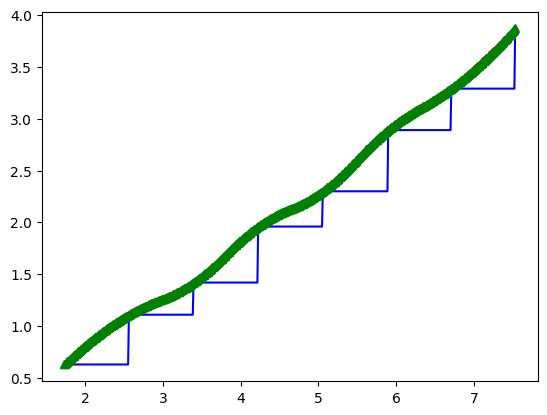

In [17]:
plt.plot(x, y, 'r--') #Базовый график
plt.plot(new_x, sp.interpolate.interp1d(x, y, kind='zero')(new_x), 'b-') #Интерполированный ступенчатый
plt.plot(new_x, sp.interpolate.interp1d(x, y, kind='quadratic')(new_x), 'g^-') #Интерполированный квадратичный
plt.show()

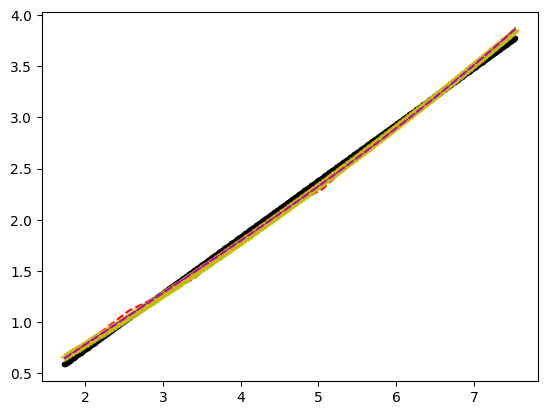

In [15]:
plt.plot(x, y, 'r--') #Базовый график
plt.plot(new_x, np.polyval(np.polyfit(x, y, deg = 1), new_x), 'k.-')# Полиномиальная аппроксимация 1й степени
plt.plot(new_x, np.polyval(np.polyfit(x, y, deg = 2), new_x), 'y+-')# Полиномиальная аппроксимация 2й степени
plt.plot(new_x, np.polyval(np.polyfit(x, y, deg = 3), new_x), 'm,--')# Полиномиальная аппроксимация 3й степени
plt.show()

## Задание 3.

Создайте функцию для кусочной интерполяции значения табличной функции в линейной функцией (функция принимает на вход точку или массив точек и рассчитывает значение функции в ней/них с учётом интервала - для каждого интервала между узлами предварительно необходимой найти коэффициенты прямой

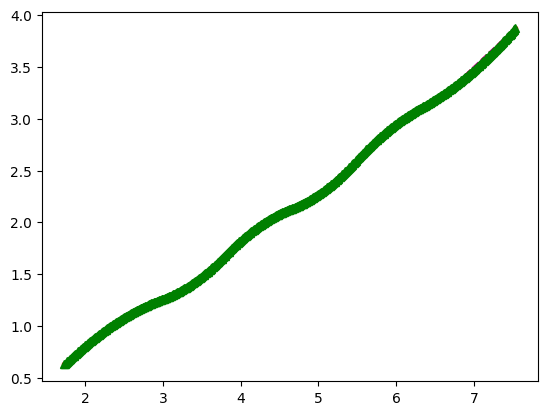

In [18]:
def interpol(x, y, new_x):
    new_y = np.zeros_like(new_x)

    k = np.diff(y) / np.diff(x)  # Угол наклона(для всех)
    b = y[:-1] - k * x[:-1]      # Смещение(для всех)

    # Для каждой точки new_x находим соответствующий интервал и вычисляем y
    for i, xi in enumerate(new_x):
        # Находим индекс интервала, в который попадает xi
        idx = np.searchsorted(x, xi) - 1

        # Обрабатываем случай, когда xi выходит за пределы x
        if idx < 0:
            idx = 0
        elif idx >= len(k):
            idx = len(k) - 1

        # Вычисляем y
        new_y[i] = k[idx] * xi + b[idx]

    return new_y

plt.plot(x, y, 'r.--') #Базовый график
plt.plot(new_x, interpol(x, y, new_x), 'm,--') #Интерполяция
plt.plot(new_x, sp.interpolate.interp1d(x, y, kind='quadratic')(new_x), 'g^-') #Интерполированный квадратичный
plt.show()

## Задание 4.

Создайте функцию для аппроксимации табличной функции методом наименьших квадратов (согласно варианту). Функция должна получать на вход numpy-массивы x, y, x_new и возвращать значение приближающей функции в точке (точках) f(x_new).

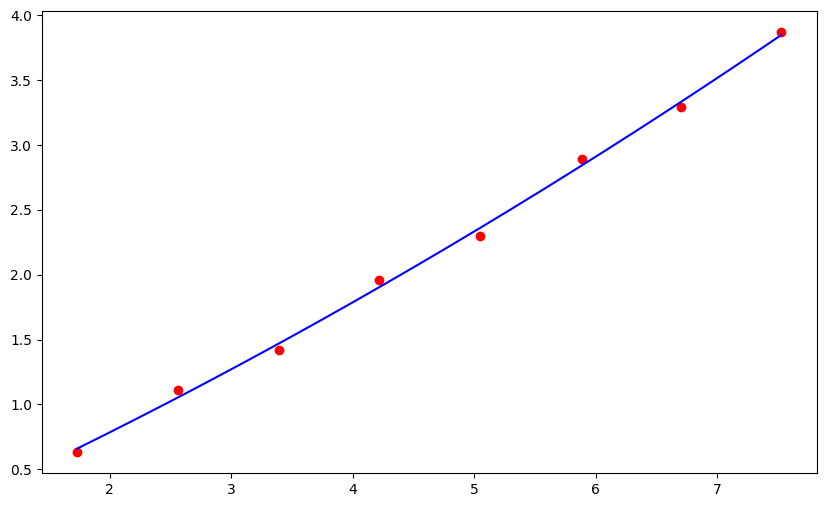

0.017372305030817506


In [19]:
def quadratic_least_squares(x, y, new_x):
    # Создаем матрицу системы
    n = len(x)
    sum_x = np.sum(x)
    sum_x2 = np.sum(x ** 2)
    sum_x3 = np.sum(x ** 3)
    sum_x4 = np.sum(x ** 4)

    sum_y = np.sum(y)
    sum_xy = np.sum(x * y)
    sum_x2y = np.sum(x ** 2 * y)

    # Матрица коэффициентов системы уравнений
    A = np.array([
        [n, sum_x, sum_x2],
        [sum_x, sum_x2, sum_x3],
        [sum_x2, sum_x3, sum_x4]
    ])

    # Вектор правой части системы уравнений
    B = np.array([sum_y, sum_xy, sum_x2y])

    # Решение системы уравнений для нахождения коэффициентов
    c,b,a = np.linalg.solve(A, B)

    new_y = a * (new_x ** 2) + b * new_x + c

    # Вычисление суммы квадратов отклонений
    y_pred = a * (x ** 2) + b * x + c
    sse = np.sum((y - y_pred) ** 2)
    return new_y, sse

new_y, sse = quadratic_least_squares(x, y, new_x)
plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='red', label='Исходные данные')
plt.plot(new_x, new_y, 'b-', label='Аппроксимация (ax² + bx + c)')
plt.show()
print(sse)

## Задание 5.

Визуально (т.е. "на глаз") оцените вид кривой наиболее точно приближающей табличную функцию (это может быть любая функция: линейная, полином, экспоненциальная, степенная и пр. - постройте некоторые из них для примера). Обоснуйте свой выбор (подкрепите графиком приближающей функции выбранного типа) .

/tmp/ipykernel_10084/1705908232.py:11: RuntimeWarning: invalid value encountered in log
  return a * np.log(b * x) + c


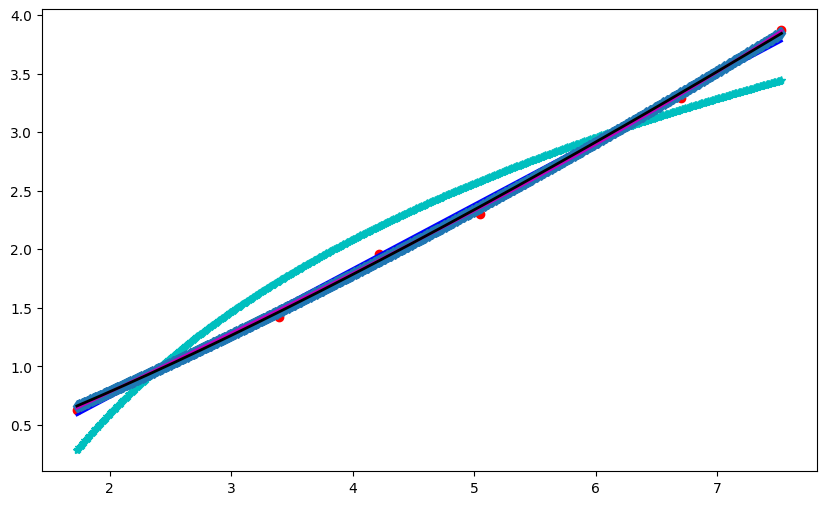

In [20]:
def lin_func(x, a, b):
    return a*x + b

def exp_func(x, a, b, c):
    return a * np.exp(b * x) + c

def rational_func(x, a, b, c, d):
    return (a * x + b) / (x**2 + c * x + d)

def log_func(x, a, b, c):
    return a * np.log(b * x) + c

def quadratic_func(x, a, b, c):
    return a * x**2 + b * x + c

def cubic_func(x,a,b,c,d):
    return a * x ** 3 + b * x ** 2 + c * x + d

def power_func(x, a, b, c):
    return a * x**b + c


plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='red', label='Исходные данные')
plt.plot(new_x, lin_func(new_x, *sp.optimize.curve_fit(lin_func, x, y)[0]) , 'b-', linewidth=2, label='Аппроксимирующая прямая')
plt.plot(new_x, exp_func(new_x, *sp.optimize.curve_fit(exp_func, x, y)[0]) , 'g--', linewidth=2)
#plt.plot(new_x, rational_func(new_x, *sp.optimize.curve_fit(rational_func, x, y)[0]) , 'b-', linewidth=2, label='Аппроксимирующая прямая') не нашло опт. параметры
plt.plot(new_x, log_func(new_x, *sp.optimize.curve_fit(log_func, x, y)[0]) , 'c*', linewidth=2)
plt.plot(new_x, quadratic_func(new_x, *sp.optimize.curve_fit(quadratic_func, x, y)[0]) , 'd-', linewidth=2)
plt.plot(new_x, cubic_func(new_x, *sp.optimize.curve_fit(cubic_func, x, y)[0]) , 'm-', linewidth=2)
plt.plot(new_x, power_func(new_x, *sp.optimize.curve_fit(power_func, x, y)[0]) , 'k-', linewidth=2)
plt.show()

Выделяется только логарифмическая функция, остальные совпадают с исходным графиком

## Задание 6

Прочитайте данные из файла в две переменные: h и t. Постройте график h(t).

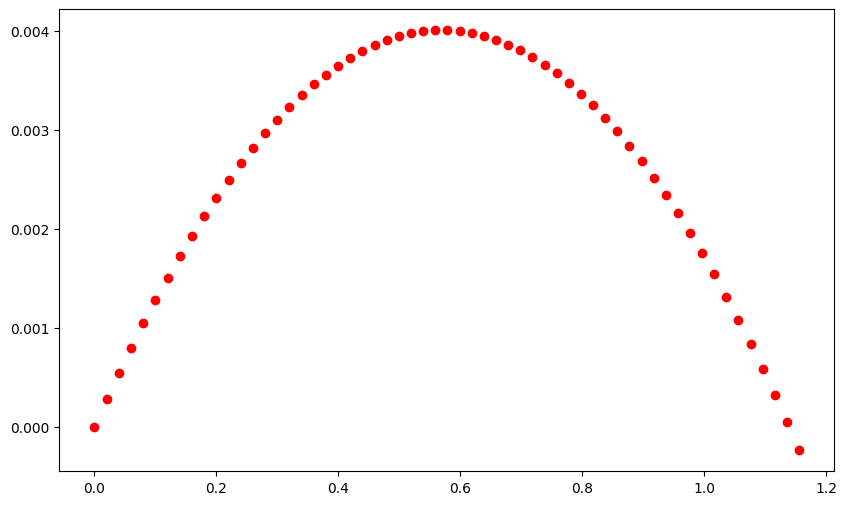

In [ ]:
readed_df = pd.read_excel("flight.xlsx")
plt.figure(figsize=(10, 6))
plt.scatter(readed_df['x'], readed_df['y'], color='red', label='Исходные данные')
plt.show()

## Задание 7

Аппроксимируйте с помощью полинома 2-й степени данные, импортированные Вами в предыдущем задании

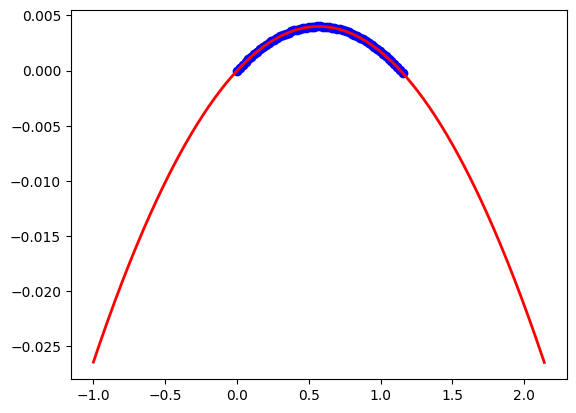

In [ ]:
new_x = np.arange(-1, 2.15, 0.01)
new_y = quadratic_func(new_x, *sp.optimize.curve_fit(quadratic_func, readed_df['x'], readed_df['y'])[0])
plt.plot(new_x, new_y, 'r-', linewidth=2)
plt.scatter(readed_df['x'], readed_df['y'], color='b')
plt.show()
save_df = pd.DataFrame({'x':new_x,'y': new_y})
save_df.to_excel("saveme.xlsx", index=False)

### Вопросы
1. Функции для поиска наименьшего и наибольших элементов в массиве.
2. Функции для сортировки элементов в массиве.
3. Понятие аппроксимации.
4. Что такое интерполяция?
5. Что такое узлы интерполяции?
6. В чем заключается задача отыскания интерполирующего многочлена?
7. Как построить интерполяционный многочлен Лагранжа?
8. Что такое сплайн? Как происходит процесс интерполирования сплайнами?
9. Что такое конечная разность первого порядка? Как она находится?
### Ответы
1. `Поиск минимума и максимума выполняется линейным проходом по массиву с последовательным сравнением элементов и обновлением экстремального значения. На практике обычно используют встроенные функции (например, min(), max()), реализующие этот алгоритм за время O(n).`
2. `Сортировка упорядочивает элементы массива по возрастанию или убыванию. Эффективные алгоритмы (быстрая сортировка, слиянием) работают за O(n log n), однако в программировании чаще применяют готовые оптимизированные методы, такие как sort().`
3. `Аппроксимация — это приближение сложных функций или данных более простыми зависимостями с минимизацией общей ошибки (например, методом наименьших квадратов). Кривая не обязана проходить через исходные точки, что позволяет сглаживать погрешности измерений.`
4. `Интерполяция — это нахождение промежуточных значений функции по известным дискретным точкам, причём строящаяся кривая проходит строго через эти узлы. Метод позволяет восстановить непрерывную зависимость внутри интервала наблюдений.`
5. `Узлы интерполяции — это известные точки, в которых заданы значения функции и через которые обязана проходить интерполирующая кривая. Они служат опорными пунктами для построения многочлена или сплайна.`
6. `Задача состоит в нахождении многочлена минимальной степени, принимающего в каждом узле те же значения, что и исходная функция.`
7. `Многочлен Лагранжа строится как сумма произведений значений функции в узлах на специальные базисные полиномы, каждый из которых равен единице в своём узле и нулю в остальных. Это даёт готовую аналитическую формулу без решения систем уравнений.`
8. `Сплайн — это кусочно-полиномиальная функция (обычно кубическая), отрезки которой соединяются в узлах с непрерывностью первых производных. Интерполяция сплайнами обеспечивает гладкую кривую без колебаний, свойственных многочленам высокой степени.`
9. `Конечная разность первого порядка — это разность значений функции в двух соседних узлах, являющаяся дискретным аналогом производной. Она вычисляется простым вычитанием: Δyi=y(i+1)−y(i)`